# Machine learning de interesse - piloto Alphaville

Este notebook acompanha os **151 contatos do distrito Alphaville** e prepara um modelo para prever resultados reais de contato.

O modelo não aprende o marcador histórico `Vip`. Os alvos possíveis são:

- `respondeu`;
- `demonstrou_interesse`;
- `aceitou_visita`;
- `participou`.

> Antes do treinamento, preencha os resultados observados em `dados_interesse_Alphaville.json`. Valores ausentes devem permanecer como `null`.

## 1. Configuração

Use o mesmo kernel Python empregado em `analise_vip_ml.ipynb`.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

import ml_interesse_distritos as ml

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

ARQUIVO_EXCEL = Path('ListagemCompleta (1).xlsx')
ARQUIVO_DADOS = Path('dados_interesse_Alphaville.json')
ARQUIVO_MODELO = Path('modelo_interesse_Alphaville.joblib')
ARQUIVO_METRICAS = Path('metricas_interesse_Alphaville.json')
DISTRITO_PILOTO = 'Alphaville'
ALVO = 'respondeu'

## 2. Atualização dos dados

A célula extrai novamente Alphaville da planilha e preserva os resultados já preenchidos, usando o campo `id`.

In [2]:
argumentos = type('Argumentos', (), {
    'arquivo': ARQUIVO_EXCEL,
    'distrito': DISTRITO_PILOTO,
    'saida': ARQUIVO_DADOS,
    'alvo': ALVO,
})()
ml.prepare(argumentos)

c:\Users\Public\processamento-imagem\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


JSON preparado: dados_interesse_Alphaville.json | registros=151 | rotulados_em_respondeu=0


## 3. Leitura e estrutura

In [3]:
payload = json.loads(ARQUIVO_DADOS.read_text(encoding='utf-8'))
registros = payload['registros']

base_modelo = ml.records_to_frame(payload, ALVO)
base_contatos = pd.DataFrame([
    {
        'id': registro['id'],
        **registro['contato'],
        **registro['origem'],
        **registro['resultados'],
    }
    for registro in registros
])

print(f"Distrito: {payload['distrito_piloto']}")
print(f"Registros: {payload['total_registros']}")
print(f"Data de referência: {payload['data_referencia']}")
display(base_contatos.head())

Distrito: Alphaville
Registros: 151
Data de referência: 2026-06-08


,id,nome,telefone,email,distrito,cidade,bairro,material,ultimo_contato,vip_historico,tentativa_contato,data_tentativa,canal,respondeu,demonstrou_interesse,aceitou_visita,participou,observacao
0,17322,Silmara Cristina Souza Santos,,silmara@pontoaponto.com.br,Alphaville,BARUERI,Alphaville Industrial,PRINCÍPIOS - Impresso | 22/09/2008,2008-09-22,False,False,None,None,None,None,None,None,None
1,73049,Gilvandete Josefa de Souza,+551156238476 +551145022586,gilvandete@flytour.com.br,Alphaville,BARUERI,Alphaville Industrial,PRINCÍPIOS - Impresso | 11/05/2010*-*REVISTA V...,2010-05-11,False,False,None,None,None,None,None,None,None
2,167610,Iara Alves Godoy,,,Alphaville,BARUERI,Alphaville Industrial,,2008-10-16,False,False,None,None,None,None,None,None,None
3,169043,Idalina .,,,Alphaville,BARUERI,Alphaville Industrial,REVISTA VIVA COM ESPERANÇA - Impresso | 14/11/...,2008-11-14,False,False,None,None,None,None,None,None,None
4,169047,Fernanda Silva,,nandi-silva@hotmail.com,Alphaville,BARUERI,Alphaville Industrial,REVISTA VIVA COM ESPERANÇA - Impresso | 14/11/...,2008-11-14,False,False,None,None,None,None,None,None,None


## 4. Qualidade operacional dos contatos

,quantidade
total,151
com telefone,122
telefone válido,69
com email,125
email válido,125
com descrição,29


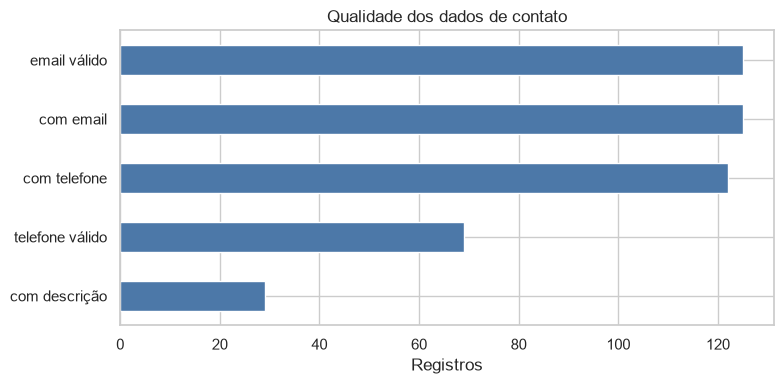

In [4]:
qualidade = pd.Series({
    'total': len(base_modelo),
    'com telefone': int(base_modelo['tem_telefone'].sum()),
    'telefone válido': int(base_modelo['telefone_valido'].sum()),
    'com email': int(base_modelo['tem_email'].sum()),
    'email válido': int(base_modelo['email_valido'].sum()),
    'com descrição': int(base_modelo['tem_descricao'].sum()),
}, name='quantidade')
display(qualidade.to_frame())

ax = qualidade.drop('total').sort_values().plot(
    kind='barh', figsize=(8, 4), color='#4C78A8'
)
ax.set(title='Qualidade dos dados de contato', xlabel='Registros', ylabel='')
plt.tight_layout()
plt.show()

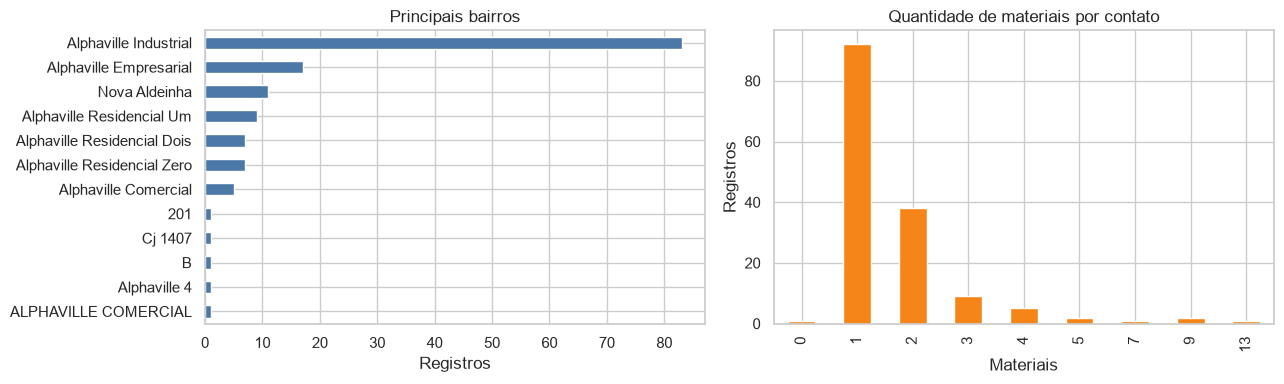

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
base_contatos['bairro'].fillna('Não informado').value_counts().head(12).sort_values().plot(
    kind='barh', ax=axes[0], color='#4C78A8'
)
axes[0].set(title='Principais bairros', xlabel='Registros', ylabel='')

base_modelo['materiais_quantidade'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#F58518'
)
axes[1].set(title='Quantidade de materiais por contato', xlabel='Materiais', ylabel='Registros')
plt.tight_layout()
plt.show()

## 5. Acompanhamento dos resultados

Escolha o alvo na variável `ALVO` da primeira célula. O treinamento exige no mínimo 30 registros rotulados, sendo pelo menos 5 positivos e 5 negativos.

In [6]:
resumo_alvos = []
for alvo in ml.TARGETS:
    valores = base_contatos[alvo]
    resumo_alvos.append({
        'alvo': alvo,
        'rotulados': int(valores.notna().sum()),
        'positivos': int(valores.eq(True).sum()),
        'negativos': int(valores.eq(False).sum()),
        'pendentes': int(valores.isna().sum()),
    })

resumo_alvos = pd.DataFrame(resumo_alvos).set_index('alvo')
display(resumo_alvos)

,rotulados,positivos,negativos,pendentes
alvo,,,,
respondeu,0,0,0,151
demonstrou_interesse,0,0,0,151
aceitou_visita,0,0,0,151
participou,0,0,0,151


In [7]:
rotulados = base_contatos[base_contatos[ALVO].notna()].copy()
pendentes = base_contatos[base_contatos[ALVO].isna()].copy()

print(f'Alvo selecionado: {ALVO}')
print(f'Rotulados: {len(rotulados)} | Pendentes: {len(pendentes)}')
display(pendentes[['id', 'nome', 'telefone', 'email', 'ultimo_contato']].head(20))

Alvo selecionado: respondeu
Rotulados: 0 | Pendentes: 151


,id,nome,telefone,email,ultimo_contato
0,17322,Silmara Cristina Souza Santos,,silmara@pontoaponto.com.br,2008-09-22
1,73049,Gilvandete Josefa de Souza,+551156238476 +551145022586,gilvandete@flytour.com.br,2010-05-11
2,167610,Iara Alves Godoy,,,2008-10-16
3,169043,Idalina .,,,2008-11-14
4,169047,Fernanda Silva,,nandi-silva@hotmail.com,2008-11-14
5,169049,Ana Claudia,,,2008-11-14
6,169050,Priscilla .,,,2008-11-14
7,169054,Antonio ( Sindico),,,2008-11-14
8,169057,Edna .,,,2008-11-14
9,169060,Jessica .,,,2008-11-14


## 6. Treinamento e validação

Esta célula não inventa rótulos. Enquanto a amostra mínima não existir, ela apenas informa o progresso necessário.

In [8]:
contagens = base_modelo.loc[base_modelo[ALVO].notna(), ALVO].astype(int).value_counts()
pode_treinar = (
    base_modelo[ALVO].notna().sum() >= 30
    and len(contagens) == 2
    and contagens.min() >= 5
)

if pode_treinar:
    argumentos_treino = type('Argumentos', (), {
        'dados': ARQUIVO_DADOS,
        'alvo': ALVO,
        'modelo': ARQUIVO_MODELO,
        'metricas': ARQUIVO_METRICAS,
    })()
    ml.train(argumentos_treino)
    metricas = json.loads(ARQUIVO_METRICAS.read_text(encoding='utf-8'))
    display(pd.Series({
        'registros rotulados': metricas['registros_rotulados'],
        'positivos': metricas['positivos'],
        'negativos': metricas['negativos'],
        'ROC AUC': metricas['roc_auc'],
        'Average Precision': metricas['average_precision'],
        'baseline recência ROC AUC': metricas['baseline_recencia_roc_auc'],
        'baseline recência AP': metricas['baseline_recencia_average_precision'],
    }, name='resultado').to_frame())
else:
    positivos = int(contagens.get(1, 0))
    negativos = int(contagens.get(0, 0))
    print('Modelo ainda não treinado.')
    print(f'Rotulados: {int(base_modelo[ALVO].notna().sum())}/30')
    print(f'Positivos: {positivos}/5 | Negativos: {negativos}/5')

Modelo ainda não treinado.
Rotulados: 0/30
Positivos: 0/5 | Negativos: 0/5


## 7. Interpretação do modelo

In [9]:
if ARQUIVO_MODELO.exists():
    pacote = joblib.load(ARQUIVO_MODELO)
    pipeline = pacote['pipeline']
    nomes = pipeline.named_steps['preprocessamento'].get_feature_names_out()
    coeficientes = pipeline.named_steps['classificador'].coef_[0]
    importancia = pd.DataFrame({
        'atributo': nomes,
        'coeficiente': coeficientes,
    }).sort_values('coeficiente')
    extremos = pd.concat([importancia.head(10), importancia.tail(10)])
    plt.figure(figsize=(9, 7))
    sns.barplot(
        data=extremos,
        y='atributo',
        x='coeficiente',
        hue=extremos['coeficiente'].gt(0),
        palette={True: '#F58518', False: '#4C78A8'},
        legend=False,
    )
    plt.title(f'Fatores associados ao alvo: {pacote["alvo"]}')
    plt.tight_layout()
    plt.show()
else:
    print('A interpretação ficará disponível depois do primeiro treinamento válido.')

A interpretação ficará disponível depois do primeiro treinamento válido.


## 8. Teste externo em outro distrito

Altere `DISTRITO_TESTE`. A previsão só é gerada quando existe um modelo treinado.

In [10]:
DISTRITO_TESTE = 'Pinheiros'
ARQUIVO_PREVISAO = Path(f'previsoes_interesse_{DISTRITO_TESTE}.csv')

if ARQUIVO_MODELO.exists():
    argumentos_previsao = type('Argumentos', (), {
        'modelo': ARQUIVO_MODELO,
        'arquivo': ARQUIVO_EXCEL,
        'distrito': DISTRITO_TESTE,
        'saida': ARQUIVO_PREVISAO,
    })()
    ml.predict(argumentos_previsao)
    previsoes = pd.read_csv(ARQUIVO_PREVISAO)
    display(previsoes.head(30))
else:
    print('Teste externo aguardando um modelo treinado com resultados reais.')

Teste externo aguardando um modelo treinado com resultados reais.


## Conclusão operacional

1. Registre resultados reais no JSON.
2. Acompanhe o equilíbrio entre positivos e negativos.
3. Treine somente após atingir a amostra mínima.
4. Compare o modelo com a regra simples de recência.
5. Valide em outro distrito antes de usar a previsão como fila operacional.

O score deve ordenar revisões e contatos. Ele não deve tomar decisões automáticas sobre pessoas.